# AusLAMP Victoria: Quick Start Demo

**Goal**: Demonstrate the new unified MTH5 reader for both EDL and LEMI-424 data.

**Key Features**:
- Single reader for both instrument types
- Automatic instrument detection and calibration
- Read directly from GA's MTH5 files (no ASCII conversion needed)
- Correct Bartington Mag-03 calibration applied

**Data Source**: `E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\` and `LEMI_MTH5\`

In [1]:
import sys
sys.path.insert(0, '../src')

from readers import read_station, get_station_metadata, get_all_metadata
from config import DataPaths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Read EDL Station (VIC001)

EDL data:
- Raw data in µV (uncalibrated in MTH5)
- Reader applies correct Bartington Mag-03 calibration
- Sample rate: 10 Hz

In [2]:
# Get metadata first
edl_file = DataPaths.EDL_MTH5 / 'VIC001.h5'
metadata_edl = get_station_metadata(edl_file)

print("VIC001 Metadata:")
for key, value in metadata_edl.items():
    print(f"  {key}: {value}")

VIC001 Metadata:
  station_id: VIC001
  latitude: -38.91854
  longitude: 146.44154
  elevation: 90.0
  declination: 12.45
  declination_model: AGRF
  comments: Ex and Ey dipoles deployed in S-N and W-E directions, channels 0-2 (magnetic fields) and 3-5 (electric fields) were swapped .
  channels_recorded: ['bx', 'by', 'bz', 'ex', 'ey']
  start_time: 2014-04-11 06:00:00+00:00
  end_time: 2014-05-08 00:59:59.900000+00:00
  sample_rate: 10.0
  n_runs: 1
  instrument: EDL


In [20]:
# Read data (load first hour for quick demo)
df_edl = read_station(edl_file, channels='magnetic', verbose=True)
df_edl_sample = df_edl.iloc[36000:72000]  # Second hour at 10 Hz

print("\nSample data:")
df_edl_sample.head()

Reading VIC001.h5 (Instrument: EDL)
  Loading 1 run(s): ['20140411060000']
    Run 20140411060000: 23,148,000 samples at 10.0 Hz
  Total: 23,148,000 samples, ['BX', 'BY', 'BZ']
  Time range: 2014-04-11 06:00:00+00:00 to 2014-05-08 00:59:59.900000+00:00

Sample data:


,BX,BY,BZ
time,,,
2014-04-11 07:00:00+00:00,22099.049,-1570.170,-53827.1300
2014-04-11 07:00:00.100000+00:00,22099.077,-1570.163,-53827.2000
2014-04-11 07:00:00.200000+00:00,22099.063,-1570.149,-53827.2175
2014-04-11 07:00:00.300000+00:00,22099.042,-1570.184,-53827.2000
2014-04-11 07:00:00.400000+00:00,22099.056,-1570.191,-53827.2350


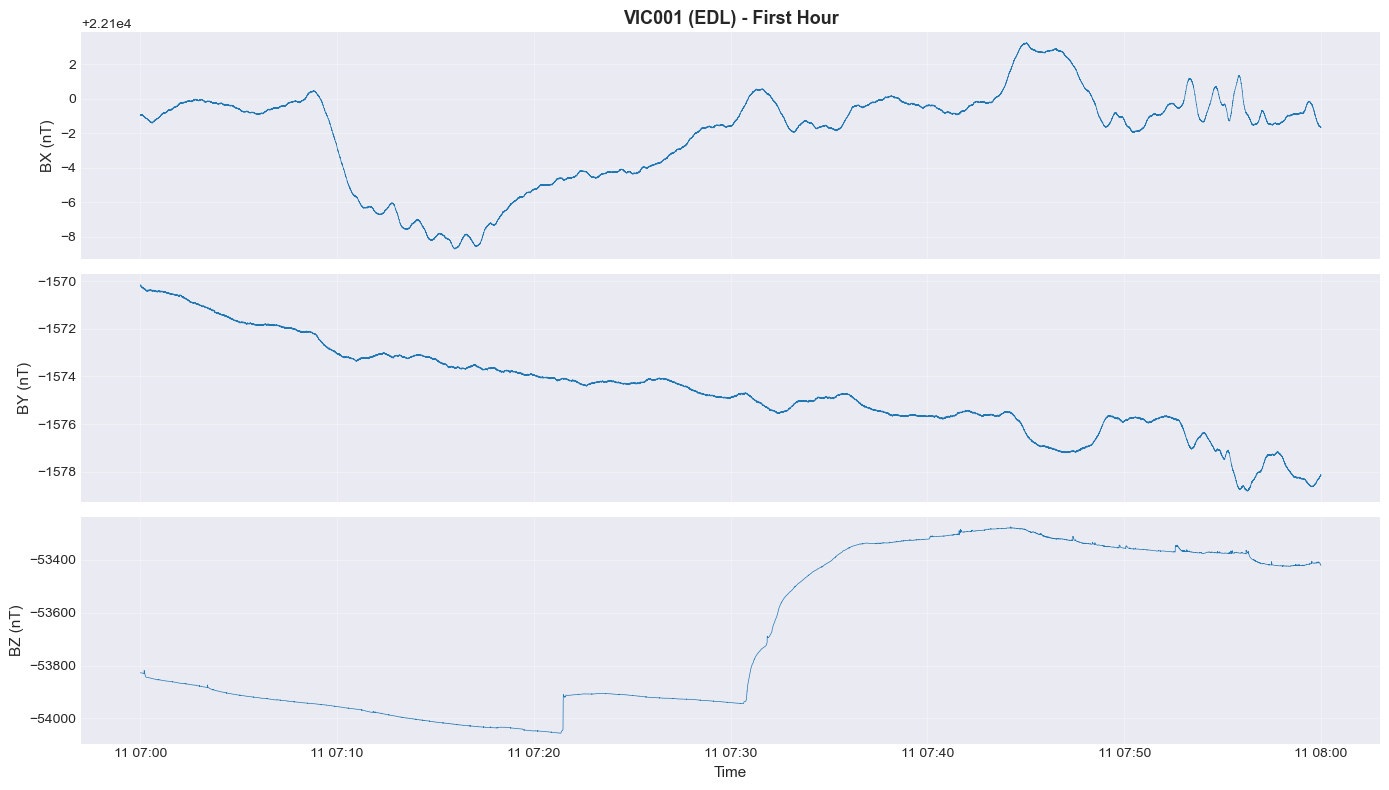


Statistics:
                 BX            BY            BZ
count  36000.000000  36000.000000  36000.000000
mean   22098.034844  -1574.614916 -53672.733610
std        2.748122      1.934833    296.435372
min    22091.286000  -1578.815000 -54056.082500
25%    22095.892000  -1575.715750 -53936.295000
50%    22099.000000  -1574.783000 -53853.835000
75%    22099.742000  -1573.327000 -53359.372500
max    22103.256000  -1570.149000 -53275.215000


In [21]:
# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, ch in enumerate(['BX', 'BY', 'BZ']):
    axes[i].plot(df_edl_sample.index, df_edl_sample[ch], linewidth=0.5)
    axes[i].set_ylabel(f'{ch} (nT)', fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('VIC001 (EDL) - First Hour', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Time', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(df_edl_sample.describe())

## 2. Read LEMI-424 Station (VIC065R)

LEMI-424 data:
- Already calibrated in nT
- Sample rate: 1 Hz
- Multiple runs (long deployment with battery swaps)

In [13]:
# Get metadata
lemi_file = DataPaths.LEMI_MTH5 / 'VIC065R.h5'
metadata_lemi = get_station_metadata(lemi_file)

print("VIC065R Metadata:")
for key, value in metadata_lemi.items():
    print(f"  {key}: {value}")

VIC065R Metadata:
  station_id: VIC065R
  latitude: -36.52641
  longitude: 143.96562
  elevation: 142.0
  declination: 10.682
  declination_model: AGRF
  comments: 
  channels_recorded: ['bx', 'by', 'bz', 'ex', 'ey', 'temperature_e', 'temperature_h']
  start_time: 2016-06-22 00:38:00+00:00
  end_time: 2017-01-17 23:59:59+00:00
  sample_rate: 1.0
  n_runs: 4
  instrument: LEMI-424


In [15]:
# Read data (load first 24 hours)
df_lemi = read_station(lemi_file, channels='magnetic', verbose=True)
df_lemi_sample = df_lemi.iloc[36000:86400]  # First 24 hours at 1 Hz

print("\nSample data:")
df_lemi_sample.head()

Reading VIC065R.h5 (Instrument: LEMI-424)
  Loading 4 run(s): ['20160622003800', '20160811000000', '20160921000000', '20161208000000']
    Run 20160622003800: 2,589,720 samples at 1.0 Hz
    Run 20160811000000: 2,592,000 samples at 1.0 Hz
    Run 20160921000000: 1,987,200 samples at 1.0 Hz
    Run 20161208000000: 3,542,400 samples at 1.0 Hz
  Total: 10,711,320 samples, ['BX', 'BY', 'BZ']
  Time range: 2016-06-22 00:38:00+00:00 to 2017-01-17 23:59:59+00:00

Sample data:


,BX,BY,BZ
time,,,
2016-06-22 10:38:00+00:00,23925.668,-168.301,-52538.688
2016-06-22 10:38:01+00:00,23925.664,-168.313,-52538.680
2016-06-22 10:38:02+00:00,23925.686,-168.301,-52538.672
2016-06-22 10:38:03+00:00,23925.707,-168.309,-52538.691
2016-06-22 10:38:04+00:00,23925.707,-168.297,-52538.695


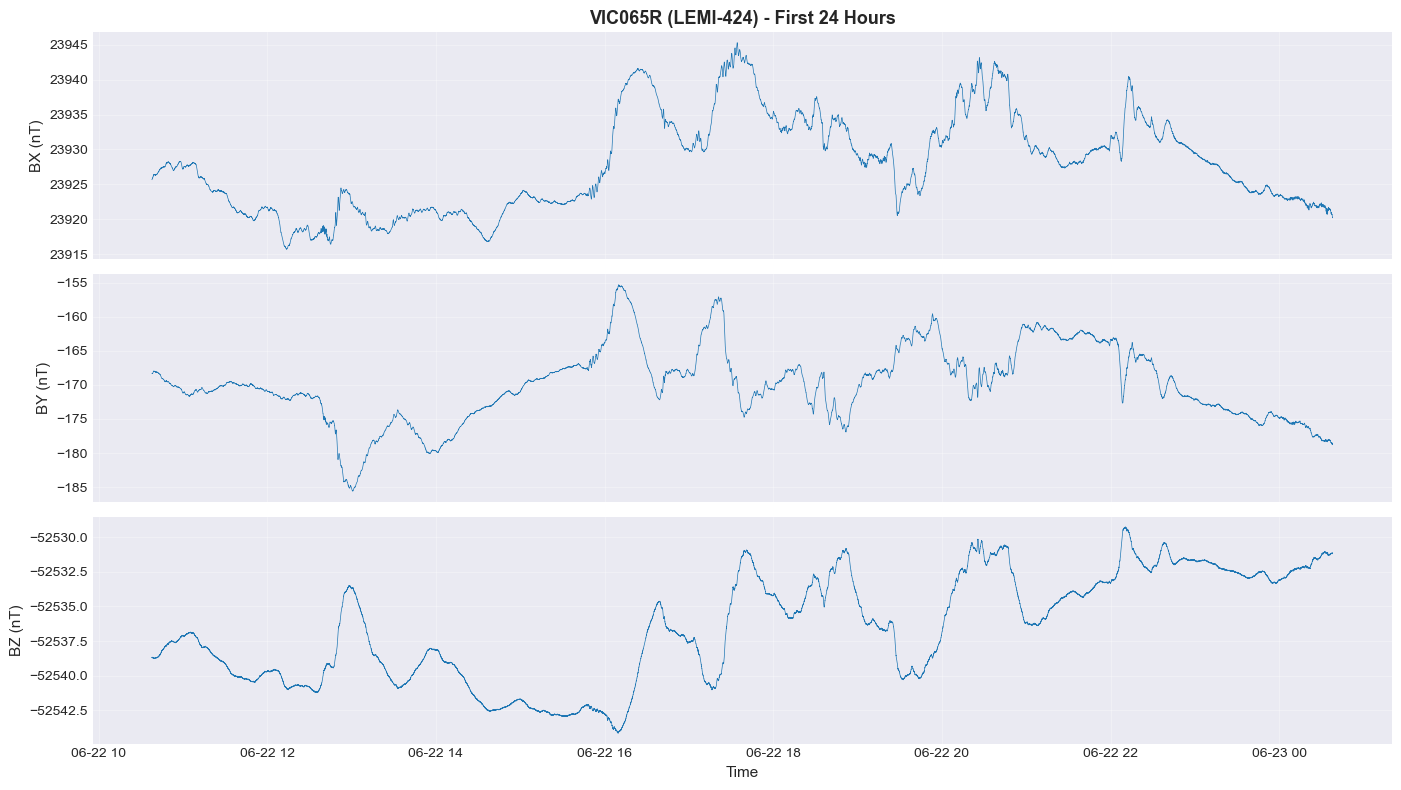


Statistics:
                 BX            BY            BZ
count  50400.000000  50400.000000  50400.000000
mean   23927.869174   -169.969721 -52536.579415
std        6.845037      5.435655      3.894916
min    23915.715000   -185.602000 -52544.172000
25%    23922.189000   -173.602000 -52540.004000
50%    23927.631000   -170.161000 -52536.465000
75%    23932.893000   -167.120000 -52532.891000
max    23945.305000   -155.292000 -52529.242000


In [16]:
# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, ch in enumerate(['BX', 'BY', 'BZ']):
    axes[i].plot(df_lemi_sample.index, df_lemi_sample[ch], linewidth=0.5)
    axes[i].set_ylabel(f'{ch} (nT)', fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('VIC065R (LEMI-424) - First 24 Hours', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Time', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(df_lemi_sample.describe())

## 3. Compare Field Strengths

Calculate horizontal and total field for both stations.

In [17]:
# Calculate derived quantities
for df, name in [(df_edl_sample, 'VIC001 (EDL)'), (df_lemi_sample, 'VIC065R (LEMI-424)')]:
    h_field = np.sqrt(df['BX']**2 + df['BY']**2)
    f_field = np.sqrt(df['BX']**2 + df['BY']**2 + df['BZ']**2)

    print(f"\n{name}:")
    print(f"  BX: {df['BX'].mean():.2f} ± {df['BX'].std():.2f} nT")
    print(f"  BY: {df['BY'].mean():.2f} ± {df['BY'].std():.2f} nT")
    print(f"  BZ: {df['BZ'].mean():.2f} ± {df['BZ'].std():.2f} nT")
    print(f"  H (horizontal): {h_field.mean():.2f} nT")
    print(f"  F (total): {f_field.mean():.2f} nT")


VIC001 (EDL):
  BX: 22098.03 ± 2.75 nT
  BY: -1574.61 ± 1.93 nT
  BZ: -53672.73 ± 296.44 nT
  H (horizontal): 22154.06 nT
  F (total): 58065.29 nT

VIC065R (LEMI-424):
  BX: 23927.87 ± 6.85 nT
  BY: -169.97 ± 5.44 nT
  BZ: -52536.58 ± 3.89 nT
  H (horizontal): 23928.47 nT
  F (total): 57729.23 nT


## 4. Load All Metadata

Get metadata for all sites without loading full time series.

In [18]:
# Load all EDL metadata
print("Loading EDL metadata...")
df_edl_meta = get_all_metadata(DataPaths.EDL_MTH5)

# Load all LEMI metadata
print("\nLoading LEMI-424 metadata...")
df_lemi_meta = get_all_metadata(DataPaths.LEMI_MTH5)

# Combine
df_all_meta = pd.concat([df_edl_meta, df_lemi_meta], ignore_index=True)

print(f"\nTotal sites: {len(df_all_meta)}")
print(f"  EDL: {len(df_edl_meta)}")
print(f"  LEMI-424: {len(df_lemi_meta)}")

df_all_meta.head(10)

Loading EDL metadata...
Found 81 MTH5 files in EDL_MTH5
Successfully extracted metadata from 81 stations

Loading LEMI-424 metadata...
Found 19 MTH5 files in LEMI_MTH5
Successfully extracted metadata from 19 stations

Total sites: 100
  EDL: 81
  LEMI-424: 19


,station_id,latitude,longitude,elevation,declination,declination_model,comments,channels_recorded,start_time,end_time,sample_rate,n_runs,instrument,mth5_file,duration_days
0,VIC001,-38.91854,146.44154,90.0,12.450,AGRF,Ex and Ey dipoles deployed in S-N and W-E dire...,"[bx, by, bz, ex, ey]",2014-04-11 06:00:00+00:00,2014-05-08 00:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,26.791666
1,VIC002,-38.34441,142.46660,33.0,10.583,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-13 00:00:00+00:00,2014-06-06 03:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,24.166666
2,VIC003,-38.51675,142.97397,50.0,10.850,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-12 03:00:00+00:00,2014-06-06 22:59:59.900000+00:00,10.0,5,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,25.833332
3,VIC005,-38.51191,143.98602,184.0,11.450,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-11 00:00:00+00:00,2014-05-28 22:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,17.958332
4,VIC006,-38.44941,144.99806,120.0,11.750,AGRF,nan,"[bx, by, bz, ex, ey]",2014-04-06 07:00:00+00:00,2014-05-08 21:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,32.624999
5,VIC007,-38.49665,145.51129,NaN,12.000,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-08 08:00:00+00:00,2014-05-26 17:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,18.416666
6,VIC008,-38.50123,145.99519,46.0,12.218,AGRF,nan,"[bx, by, bz, ex, ey]",2014-04-09 02:00:00+00:00,2014-05-07 21:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,28.833332
7,VIC010,-38.46585,147.02672,3.0,12.460,AGRF,nan,"[bx, by, bz, ex, ey]",2014-04-11 05:00:00+00:00,2014-05-07 01:59:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,25.874999
8,VIC011,-38.03095,141.02692,30.0,9.810,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-18 07:00:00+00:00,2014-06-09 21:59:59.900000+00:00,10.0,2,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,22.624999
9,VIC013,-37.95552,141.50978,156.0,10.037,AGRF,nan,"[bx, by, bz, ex, ey]",2014-05-16 04:00:00+00:00,2014-06-10 04:25:59.900000+00:00,10.0,1,EDL,E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_MTH5\V...,25.018054


In [10]:
# Summary by instrument
print("\nRecording Duration Summary:")
print(df_all_meta.groupby('instrument')['duration_days'].describe())


Recording Duration Summary:
            count       mean        std        min        25%        50%  \
instrument                                                                 
EDL          81.0  25.676482  11.089599   9.291666  16.916666  22.124999   
LEMI-424     19.0  55.402858  48.602235  32.741528  35.337286  37.753461   

                  75%         max  
instrument                         
EDL         32.824304   56.527777  
LEMI-424    39.431267  209.973600  


## Summary

The new unified MTH5 reader:

✅ **Works with both EDL and LEMI-424** automatically  
✅ **Applies correct calibration** (Bartington Mag-03 for EDL)  
✅ **Returns consistent DataFrame format**  
✅ **Handles multiple runs** (LEMI-424 long deployments)  
✅ **Fast metadata extraction** without loading full datasets  

**Next steps**:
1. Build SQLite metadata database for all 100 sites
2. QA/QC analysis with the new reader
3. Site location maps and timeline plots
4. MT processing workflow